# SCBA Visualization
30 June 2026 \
Yong Da Li

Jupyter Notebook used for plotting the SCBA variables (G, P, W, Sigma).
The data files are saved as `scba_variables_g_greater_iter00.npy`.
The data prefix is always `scba_variables`.
The files are {g, p, w, sigma} x {greater, lesser, retarded/retarded_hermitian} x {iteration}.

If you load the file with `np.load()`, the object is a 3-D numpy array.
The indexing is {iteration, energy, nnz}.
The iteration index is the iteration of the SCBA loop.
The energy index is the energy grid used.
The nnz index is the non-zero orbital-orbital interaction index. 

The `scba_container` class helps structure the code and allows re-use.

## Note nnz index
For example, there are 768 electrons in the `w90/carbon-nanotube/gw` example.
The Hamiltonian matrix is 768 x 768.
But only 43824 matrix entries are non-zero.
That is 43824/(768*768) = 7.43% of matrix entries.
However, it would still be too data to save all 43824 nnz since each nnz contains all the energy indices as well.
Thus a parameter called `num_nnz_samples_scba_variables` is used in the `quatrex_config.toml` to specify how many of the 43824 indices should be saved. 
By default, this `num_nnz_samples_scba_variables=100`.
So 100 uniformly random samples from the 43824 nnz are saved.

The output file `scba_variables_sample_indices.npy` is a 1-D array that is length 100. It specifies which of the 43824 nnz entries were saved.

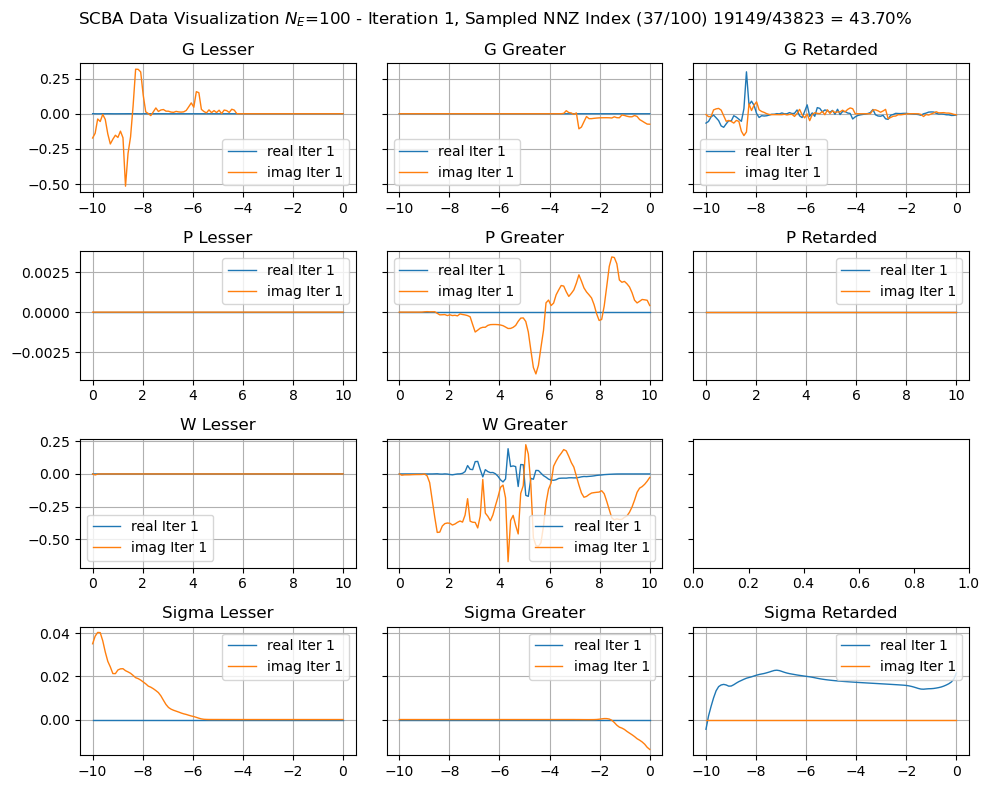

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# data class to hold data across iterations
from scba_container.scba_container import SCBAContainer

from quatrex.core.config import parse_config
from pathlib import Path

# === user parameters ===
quatrex_config_path = Path("./../../examples/w90/carbon-nanotube/gw/quatrex_config.toml")
data_dir = Path("./../../examples/w90/carbon-nanotube/gw/outputs")

iteration_to_plot = 1
sample_idx_to_plot = 37

# region: === load SCBA data ===
config = parse_config(quatrex_config_path)

max_idx = 43823  # total nnz entries - 1, hardcoded for w90/carbon-nanotube/gw example
nnz_sample_indices = np.load(f"{data_dir}/scba_variables_sample_indices.npy")
num_nnz = len(nnz_sample_indices)

SCBADataObj = SCBAContainer(
    max_iterations=config.scba.max_iterations,
    energy_window_min=config.electron.energy_window_min,
    energy_window_max=config.electron.energy_window_max,
    energy_window_num=config.electron.energy_window_num,
    num_nnz=num_nnz,
)

SCBADataObj.load_sample_indices(data_dir)
# SCBADataObj.load_adaptive_grids(data_dir)     # only used if adaptive grids are enabled in the SCBA calculation (see branch adaptive_energy_grids_dev or contact Yong Da Li)

for i in range(config.scba.max_iterations):
    SCBADataObj.load_g_data(data_dir, iteration=i)
    SCBADataObj.load_p_data(data_dir, iteration=i)
    SCBADataObj.load_w_data(data_dir, iteration=i)
    SCBADataObj.load_sigma_data(data_dir, iteration=i)

assert (
    sample_idx_to_plot <= num_nnz
), f"sample_idx_to_plot={sample_idx_to_plot} exceeds num_samples={num_nnz}"
nnz_index_to_plot = SCBADataObj.sample_indices[sample_idx_to_plot]
# endregion

# region: === plotting ===
fig, axs = plt.subplots(4, 3, figsize=(10, 8), sharey='row')

SCBADataObj.plot_iteration(
    axs,
    iteration_to_plot,
    sample_idx_to_plot,
)

fig.suptitle(
    f"SCBA Data Visualization $N_E$={config.electron.energy_window_num} - Iteration {iteration_to_plot}, Sampled NNZ Index ({sample_idx_to_plot}/{num_nnz}) {nnz_index_to_plot}/{max_idx} = {nnz_index_to_plot/max_idx:.2%}"
)
plt.tight_layout()
plt.show()
# endregion


# Overlapping plots with fading alpha
Run the previous cell to load the data.
Then run this cell to plot the overlapping iteration data.
You can change the `iterations` variable to be an iterable object (ex. `range` or `list`) of what iterations you want to plot.
The alpha (fading colour effect) will scale automatically.

Plotted iteration 0 with alpha=0.15
Plotted iteration 1 with alpha=0.23
Plotted iteration 2 with alpha=0.31
Plotted iteration 3 with alpha=0.38
Plotted iteration 4 with alpha=0.46
Plotted iteration 5 with alpha=0.54
Plotted iteration 6 with alpha=0.62
Plotted iteration 7 with alpha=0.69
Plotted iteration 8 with alpha=0.77
Plotted iteration 9 with alpha=0.85


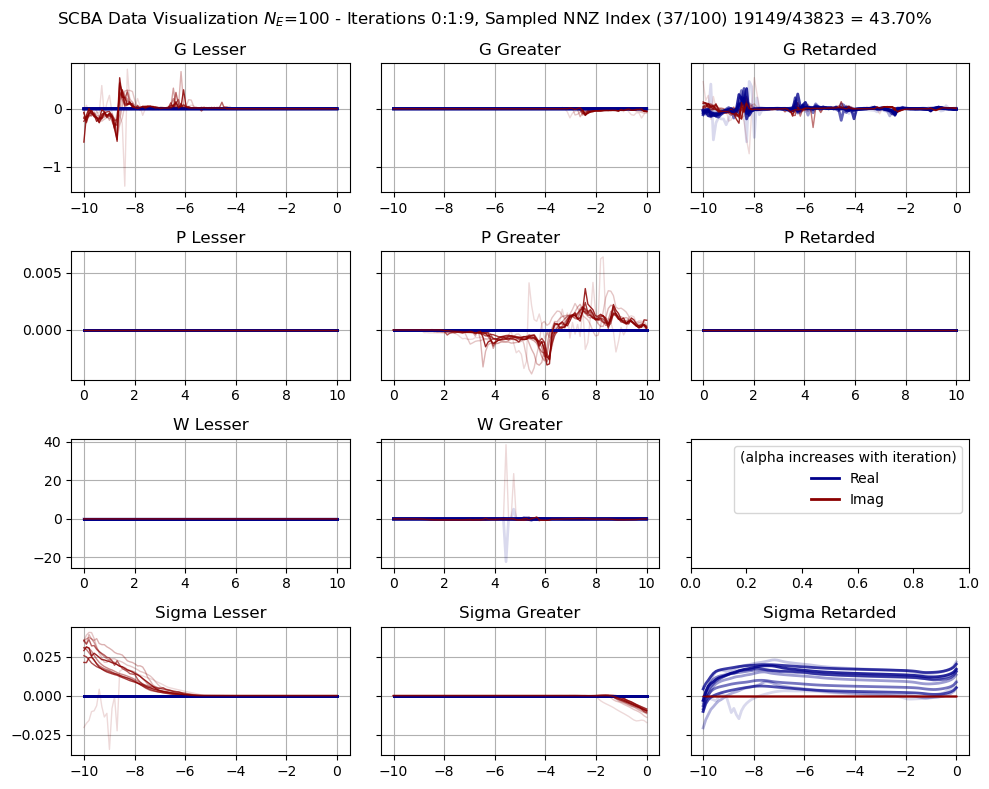

In [15]:
# custom legend
from matplotlib.lines import Line2D

# === plot iteration on top of each other with changing alpha ===
fig, axs = plt.subplots(4, 3, figsize=(10, 8), sharey='row')

# === user parameters ===
sample_idx_to_plot = 37

iterations = range(0, 10, 1)  # iterations to plot, e.g., range(0, 10, 1) for iterations 0 to 9

colorReal = "darkblue"
colorImag = "darkred"

# region: === plotting ===
for iteration_to_plot in iterations:
    assert (
        sample_idx_to_plot <= num_nnz
    ), f"sample_idx_to_plot={sample_idx_to_plot} exceeds num_nnz={num_nnz}"
    nnz_index_to_plot = SCBADataObj.sample_indices[sample_idx_to_plot]

    alpha = 0.15 + 0.7 * (iteration_to_plot - min(iterations))/(max(iterations) - min(iterations))
    SCBADataObj.plot_iteration(
        axs,
        iteration_to_plot,
        sample_idx_to_plot,
        alpha=alpha,
        colorReal=colorReal,
        colorImag=colorImag,
        linewidthReal=2,
        linewidthImag=1,
        # adaptive_start_iteration=config.scba.adaptive_start_iteration     # only used if adaptive grids are enabled in the SCBA calculation (see branch adaptive_energy_grids_dev or contact Yong Da Li
    )

    print(
        f"Plotted iteration {iteration_to_plot} with alpha={alpha:.2f}"
    )

# remove all legends
for ax_row in axs:
    for ax in ax_row:
        try:
            ax.get_legend().remove()
            ax.grid(True)
        except:
            pass

custom_lines = [
    Line2D([0], [0], color=colorReal, lw=2),
    Line2D([0], [0], color=colorImag, lw=2),
]
axs[2, 2].legend(
    custom_lines, ["Real", "Imag"], title="(alpha increases with iteration)"
)

fig.suptitle(
    f"SCBA Data Visualization $N_E$={config.electron.energy_window_num} - Iterations {min(iterations)}:{iterations[1]-iterations[0]}:{max(iterations)}, Sampled NNZ Index ({sample_idx_to_plot}/{num_nnz}) {nnz_index_to_plot}/{max_idx} = {nnz_index_to_plot/max_idx:.2%}"
)
plt.tight_layout()
plt.show()
# endregion
